In [69]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import seaborn as sns

In [4]:
overlap = gpd.read_file('data\interm\mine_indig_footprint_corrected.gpkg')

In [5]:
overlap

,ID,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area,geometry
0,23,0.040195,Australia,AUS,Coal,0.040131,0,0.040131,"POLYGON ((14729248.192 -3395167.129, 14729392...."
1,30,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...",0.372366,0,0.372098,MULTIPOLYGON Z (((13644203.534 -3875200.456 0....
2,36,0.048309,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.048309,0,0.048257,"POLYGON Z ((13467053.269 -3679156.546 0.000, 1..."
3,37,0.242487,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.242487,0,0.242234,"POLYGON Z ((13465345.462 -3679101.220 0.000, 1..."
4,38,0.172674,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.172483,0,0.172483,"POLYGON ((13464785.841 -3671541.182, 13465248...."
...,...,...,...,...,...,...,...,...,...
83363,81419,1.223365,Suriname,SUR,None,1.223365,50,8248.678788,MULTIPOLYGON Z (((-5263149.431 599872.001 0.00...
83364,81424,0.072334,India,IND,"Iron Ore,Manganese",0.072334,50,7906.610298,MULTIPOLYGON Z (((8256728.655 2684373.640 0.00...
83365,81426,0.016092,China,CHN,Coal,0.016092,50,7869.303978,"POLYGON Z ((10159517.256 4407249.110 0.000, 10..."
83366,81427,0.217357,China,CHN,Coal,0.217357,50,7954.009405,"POLYGON Z ((10159158.554 4407979.891 0.000, 10..."


In [54]:
def grid_shape_constructor(resolution =1, min_lon=-180, min_lat=-90, max_lon=180, max_lat=90, crs='EPSG:4326'):
    
    
    # Generate grid cells using list comprehensions
    grid_cells = [box(lon, lat, lon + resolution, lat + resolution)
                for lon in range(min_lon, max_lon, resolution)
                for lat in range(min_lat, max_lat, resolution)]

    # Create a GeoDataFrame from the grid cells

    grid = gpd.GeoDataFrame(geometry=grid_cells, crs=crs)
    grid['id'] = np.arange(0,grid.shape[0])

    return grid

In [55]:
grid = grid_shape_constructor(resolution = 1)

In [15]:
grid.sindex.valid_query_predicates

{None,
 'contains',
 'contains_properly',
 'covered_by',
 'covers',
 'crosses',
 'intersects',
 'overlaps',
 'touches',
 'within'}

In [56]:
overlap.to_crs(grid.crs, inplace=True)
assert grid.crs == overlap.crs, 'CRS of grid and overlap do not match'

In [57]:
# centroids of the polygons

overlap_cent = overlap.copy()

overlap_cent['geometry'] = overlap_cent.centroid

C:\Users\admin\AppData\Local\Temp\ipykernel_8392\2765980213.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlap_cent['geometry'] = overlap_cent.centroid


In [58]:
jgrid = grid.sjoin(overlap_cent)

In [59]:
jgrid

,geometry,id,index_right,ID,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,2383,16324,0.627525,United States of America,USA,"Gold,Zinc",0.627525,0,0.631591
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,2382,16323,0.840749,United States of America,USA,"Gold,Zinc",0.846198,0,0.846198
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,2381,16322,2.161623,United States of America,USA,"Gold,Zinc",2.175638,0,2.175638
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,2380,16321,6.446777,United States of America,USA,"Gold,Zinc",6.446777,0,6.488587
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,14926,16324,0.627525,United States of America,USA,"Gold,Zinc",0.627525,10,376.402586
...,...,...,...,...,...,...,...,...,...,...,...
64773,"POLYGON ((180.00000 63.00000, 180.00000 64.000...",64773,10185,77098,0.396150,Russia,RUS,Coal,0.396150,0,0.398620
64773,"POLYGON ((180.00000 63.00000, 180.00000 64.000...",64773,11258,1694,0.233121,Russia,RUS,Coal,0.233121,10,342.165442
64773,"POLYGON ((180.00000 63.00000, 180.00000 64.000...",64773,26873,77098,0.396150,Russia,RUS,Coal,0.396150,10,348.174092
64773,"POLYGON ((180.00000 63.00000, 180.00000 64.000...",64773,10184,77097,0.119677,Russia,RUS,Coal,0.119677,0,0.120421


In [60]:
jgroup = jgrid.groupby(['id', 'buffer'])['overlay_area'].sum().reset_index()

In [62]:
grid = grid.merge(jgroup, on='id', how='left')

In [65]:
grid[grid['buffer'].isnull()]

,geometry,id,buffer,overlay_area
2674,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,0.0,12.717808
2675,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,10.0,12.683703
2676,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,30.0,12.683703
2677,"POLYGON ((-165.00000 64.00000, -165.00000 65.0...",2674,50.0,12.683703
3220,"POLYGON ((-162.00000 67.00000, -162.00000 68.0...",3217,30.0,9.492854
...,...,...,...,...
68633,"POLYGON ((178.00000 66.00000, 178.00000 67.000...",64416,50.0,39954.520061
68989,"POLYGON ((180.00000 62.00000, 180.00000 63.000...",64772,30.0,3.395339
68990,"POLYGON ((180.00000 62.00000, 180.00000 63.000...",64772,50.0,3.395339
68991,"POLYGON ((180.00000 63.00000, 180.00000 64.000...",64773,0.0,3.396789


In [72]:
jplot = grid[grid['buffer'].notnull()]

jplot_g = grid.groupby('buffer')

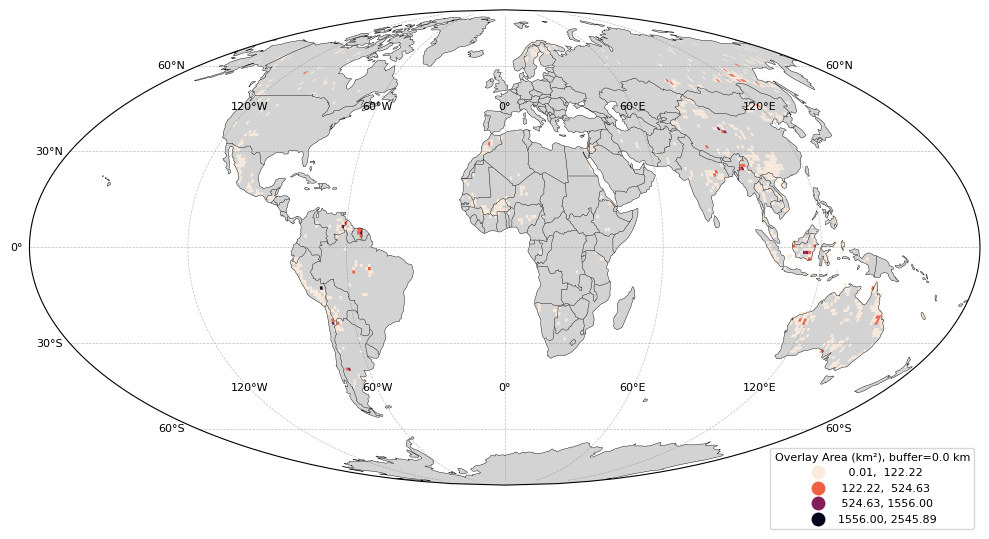

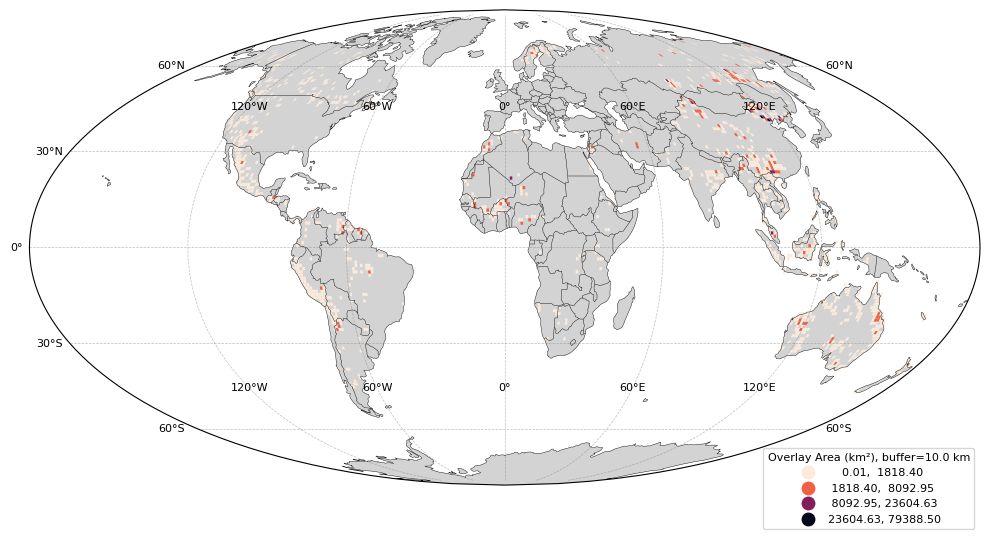

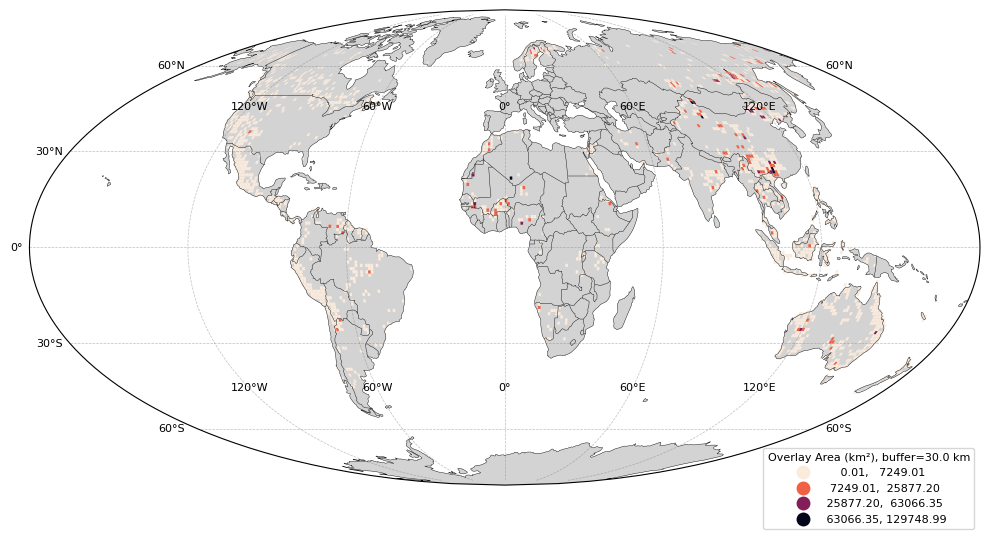

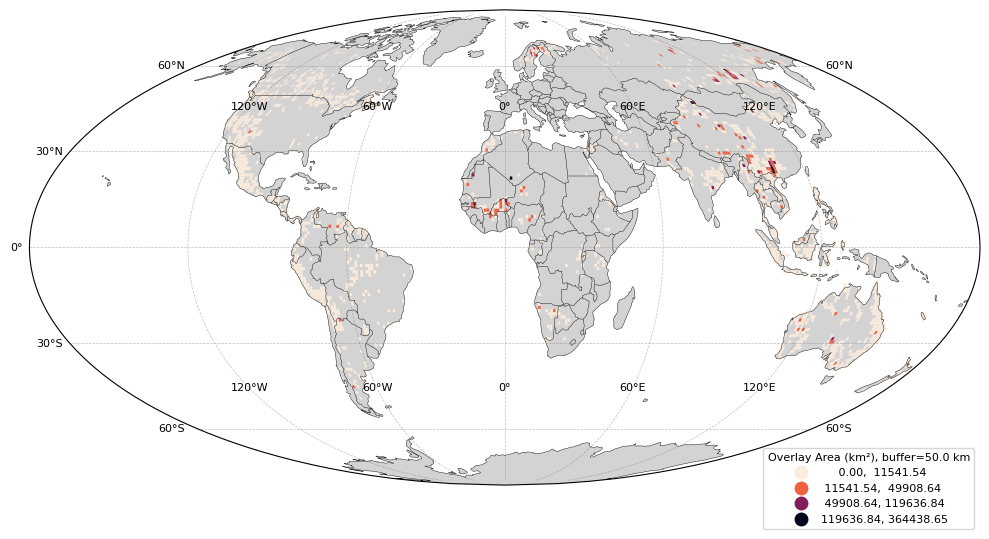

ValueError: Fewer unique values (0) than specified classes (4).

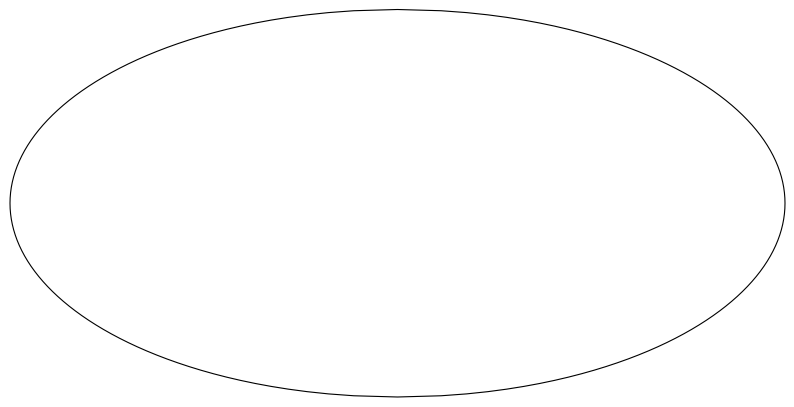

In [98]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.preprocessing import StandardScaler

import cartopy.crs as ccrs
import cartopy.feature as cfeature

scale = False

for buffer, jplot in jplot_g:
    # Create a figure and axis with a specified projection
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.Mollweide()})

    if scale:
        scaler = StandardScaler()

        # Standardize the values in the 'overlay_area' column
        jplot['overlay_area'] = scaler.fit_transform(jplot[['overlay_area']])
    
    # Plot the GeoDataFrame
    jplot.plot(column='overlay_area', scheme='fisher_jenks', k=4, legend=True, cmap='rocket_r', ax=ax, transform=ccrs.Mollweide(), legend_kwds={'fontsize': 8})

    # Add coastlines and land features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.3, edgecolor='black')

    # Customize gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'fontsize':8 }  # Rotate latitude labels
   
    gl.ylabel_style = {'fontsize':8 } 

    legend = ax.get_legend()
    legend.set_bbox_to_anchor((1, 0.09))  # Move legend outside the plot
    legend.set_title(f'Overlay Area (km²), buffer={buffer} km', prop={'size': 8})

    # Set extent to the entire globe
    ax.set_global()

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.savefig(f"fig/risk_area_{buffer}.png", bbox_inches='tight')  # Use bbox_inches='tight' to ensure the legend is not cut off
    plt.show()

In [111]:
overlap.columns

overlap['buffer'] = overlap['buffer'].astype(int)

over_zero = overlap[overlap['buffer'] == 0]

over_zero['overlay_area'].sum()

34379.28031758289

In [101]:
mine = gpd.read_file('data/mine-comm/global_mining_land_use_comm.gpkg')

In [102]:
mine.columns

Index(['area', 'admin', 'adm0_a3', 'row.id', 'list_of_commodities',
       'geometry'],
      dtype='object')

In [112]:
over_zero['overlay_area'].sum() / mine['area'].sum()

0.2865143301752631

In [116]:
for b in overlap['buffer'].unique():
    print(overlap[overlap['buffer'] == b]['overlay_area'].sum() / mine['area'].sum())

0.2865143301752631
8.444966539626266
32.406660794791094
59.969794609728254


In [117]:
buff_sum = overlap.groupby('buffer')['overlay_area'].sum()

<Axes: xlabel='buffer'>

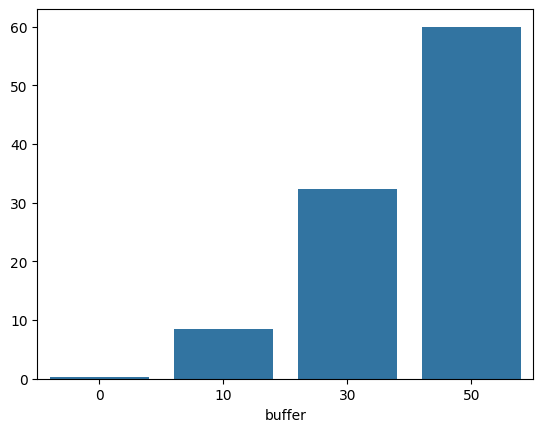

In [121]:
sns.barplot(x=buff_sum.index, y=buff_sum.values/ mine['area'].sum()) 

In [122]:
overlap.head()

,ID,mine_area,admin,adm0_a3,list_of_commodities,overlay_area,buffer,max_buffered_area,geometry
0,23,0.040195,Australia,AUS,Coal,0.040131,0,0.040131,"POLYGON ((152.65640 -27.64850, 152.65790 -27.6..."
1,30,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...",0.372366,0,0.372098,"MULTIPOLYGON Z (((141.41082 -31.97183 0.00000,..."
2,36,0.048309,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.048309,0,0.048257,"POLYGON Z ((139.57480 -30.18390 0.00000, 139.5..."
3,37,0.242487,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.242487,0,0.242234,"POLYGON Z ((139.55710 -30.18340 0.00000, 139.5..."
4,38,0.172674,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.172483,0,0.172483,"POLYGON ((139.55130 -30.11510, 139.55610 -30.1..."
